In [122]:
import requests
import pandas as pd
from datetime import datetime, timezone
from supabase import create_client, Client


def get_btc_weekly_data():
    """Extracting the 200-week data of Bitcoin from Yahoo Finance"""
    url = f"https://query1.finance.yahoo.com/v8/finance/chart/BTC-USD"
    params = {
        "period1": 0,
        "period2": int(datetime.now(timezone.utc).timestamp()),
        "interval": "1wk",
        "events": "history",
    }

    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(
        url,
        params=params,
        headers=headers,
        timeout=30
    )
    response.raise_for_status()
    data = response.json()["chart"]["result"][0]

    df = pd.DataFrame({
        "Date": pd.to_datetime(data["timestamp"], unit="s", utc=True),
        "Close": data["indicators"]["quote"][0]["close"]
    })
    return df


def calculate_200_wma():
    """Calculate the 200-week moving average BTC price"""
    df_btc = get_btc_weekly_data()

    # Calculate 200-week moving average
    df_btc["200WMA"] = df_btc["Close"].rolling(
        window=200,
        min_periods=200
    ).mean()

    result = (df_btc.dropna(subset=["200WMA"])[["Date", "200WMA"]]).tail(1)

    return result


def supabase_connection():

    SUPABASE_URL = "https://mzhomnjkelxmwlhafisp.supabase.co"
    SUPABASE_KEY = "sb_publishable_fELh3_L2GsNTRbM-Pzdaxg_Xfk5bXXL"

    # Establishing a supabase connection
    supabase: Client = create_client(
        SUPABASE_URL,
        SUPABASE_KEY
    )

    return supabase


def supabase_data_import():

    row = calculate_200_wma().iloc[0].to_dict()
    row["Date"] = row["Date"].isoformat()

    response = (
        supabase_connection()
        .table("200_wma_btc")
        .insert(row)
        .execute()
    )

    return response

def return_supabase_wma():
    response = (
        supabase
        .table("200_wma_btc")
        .select("*")
        .execute()
        )

    df = pd.DataFrame(response.data).sort_values(by="Date", ascending=False).head(1)

    return df

return_supabase_wma()["200WMA"].reset_index(drop=True)

0    64219.20043
Name: 200WMA, dtype: float64

In [100]:
def get_btc_weekly_data():
    """Extracting the 200-week data of Bitcoin from Yahoo Finance"""
    url = f"https://query1.finance.yahoo.com/v8/finance/chart/BTC-USD"
    params = {
        "period1": 0,
        "period2": int(datetime.now(timezone.utc).timestamp()),
        "interval": "1wk",
        "events": "history",
    }

    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(
        url,
        params=params,
        headers=headers,
        timeout=30
    )
    response.raise_for_status()
    data = response.json()["chart"]["result"][0]

    df = pd.DataFrame({
        "Date": pd.to_datetime(data["timestamp"], unit="s", utc=True),
        "Close": data["indicators"]["quote"][0]["close"]
    })
    return df

def get_current_btc_price():
    """Extracting the 200-week data of Bitcoin from Yahoo Finance"""
    url = f"https://query1.finance.yahoo.com/v8/finance/chart/BTC-USD"
    params = {
        "period1": int(datetime.now(timezone.utc).timestamp()),
        "period2": int(datetime.now(timezone.utc).timestamp()),
        "interval": "1d",
        "events": "history",
    }

    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(
        url,
        params=params,
        headers=headers,
        timeout=30
    )
    response.raise_for_status()
    data = response.json()["chart"]["result"][0]

    return data["indicators"]["quote"][0]["close"]

def calculate_200_wma():
    """Calculate the 200-week moving average BTC price"""
    df_btc = get_btc_weekly_data()

    # Calculate 200-week moving average
    df_btc["200WMA"] = df_btc["Close"].rolling(
        window=200,
        min_periods=200
    ).mean()

    result = df_btc.dropna(subset=["200WMA"])["200WMA"]

    return result

def calculate_buy_amount(
    btc_price,
    wma_200,
    min_buy=50,
    max_buy=100,
    min_ratio=1.0,
    max_ratio=2.0
):
    ratio = btc_price / wma_200

    # BTC at or below the 200WMA
    if ratio <= min_ratio:
        return max_buy

    # BTC at or above 2x the 200WMA
    if ratio >= max_ratio:
        return min_buy

    # Linear interpolation between $100 and $50
    position = (ratio - min_ratio) / (max_ratio - min_ratio)
    buy_amount = max_buy - position * (max_buy - min_buy)

    return round(buy_amount, 2)

def calculate_purchase(btc_price, wma_200):
    usd_amount = calculate_buy_amount(btc_price, wma_200)
    btc_amount = usd_amount / btc_price

    return {
        "btc_price": btc_price,
        "usd_amount": usd_amount,
        "btc_amount": btc_amount

btc_df = get_btc_weekly_data()
btc_df = btc_df[btc_df["Date"] >= "2020-01-01"]
btc_df["200wma"] = calculate_200_wma()
btc_df["buy_amount_btc"] = btc_df.apply(
    lambda row: calculate_purchase(row["Close"],row["200wma"])["btc_amount"],axis=1)
btc_df["buy_amount_usd"] = btc_df["buy_amount_btc"] * btc_df["Close"]

btc_df[btc_df["Date"] >= "2026-01-01"]
btc_df["current_price"] = get_current_btc_price()*len(btc_df)
btc_df["current_value"] = btc_df["current_price"] * btc_df["buy_amount_btc"]
btc_df["profit"] = btc_df["current_value"] - btc_df["buy_amount_usd"]
print(f"I would have invested a total amount of {btc_df["buy_amount_usd"].sum()} USD and my current profit would be {btc_df["profit"].sum()}")

In [113]:
btc_df = get_btc_weekly_data()
btc_df = btc_df[btc_df["Date"] >= "2020-01-01"]
btc_df["200wma"] = calculate_200_wma()
btc_df["buy_amount_btc"] = btc_df.apply(
    lambda row: calculate_purchase(row["Close"],row["200wma"])["btc_amount"],axis=1)
btc_df["buy_amount_usd"] = btc_df["buy_amount_btc"] * btc_df["Close"]

btc_df[btc_df["Date"] >= "2026-01-01"]
btc_df["current_price"] = get_current_btc_price()*len(btc_df)
btc_df["current_value"] = btc_df["current_price"] * btc_df["buy_amount_btc"]
btc_df["profit"] = btc_df["current_value"] - btc_df["buy_amount_usd"]
print(f"I would have invested a total amount of {btc_df["buy_amount_usd"].sum()} USD and my current profit would be {btc_df["profit"].sum()}")

I would have invested a total amount of 24464.77 USD and my current profit would be 34051.73668747359


In [120]:
import matplotlib.pyplot as plt

btc_df = get_btc_weekly_data()

# Calculate the 200-week MA BEFORE filtering
btc_df["200wma"] = (
    btc_df["Close"]
    .rolling(window=200, min_periods=200)
    .mean()
)

# Keep only rows where the 200WMA exists
btc_df = btc_df.dropna(subset=["200wma"])

# Last 6+ years
btc_df = btc_df[btc_df["Date"] >= "2020-01-01"].copy()

# Calculate how much BTC is bought each week
btc_df["buy_amount_usd"] = btc_df.apply(
    lambda row: calculate_buy_amount(
        row["Close"],
        row["200wma"]
    ),
    axis=1
)

btc_df["buy_amount_btc"] = (
    btc_df["buy_amount_usd"] / btc_df["Close"]
)

# Running totals
btc_df["total_usd_invested"] = (
    btc_df["buy_amount_usd"].cumsum()
)

btc_df["total_btc"] = (
    btc_df["buy_amount_btc"].cumsum()
)

# What the accumulated BTC was worth at each historical point
btc_df["portfolio_value"] = (
    btc_df["total_btc"] * btc_df["Close"]
)

# Running profit
btc_df["profit"] = (
    btc_df["portfolio_value"]
    - btc_df["total_usd_invested"]
)

# --- Flat $75/week DCA strategy ---

btc_df["flat_buy_usd"] = 75

# BTC purchased each week
btc_df["flat_buy_btc"] = (
    btc_df["flat_buy_usd"] / btc_df["Close"]
)

# Cumulative investment
btc_df["flat_total_usd_invested"] = (
    btc_df["flat_buy_usd"].cumsum()
)

# Cumulative BTC
btc_df["flat_total_btc"] = (
    btc_df["flat_buy_btc"].cumsum()
)

# Historical portfolio value
btc_df["flat_portfolio_value"] = (
    btc_df["flat_total_btc"] * btc_df["Close"]
)

# Historical profit
btc_df["flat_profit"] = (
    btc_df["flat_portfolio_value"]
    - btc_df["flat_total_usd_invested"]
)

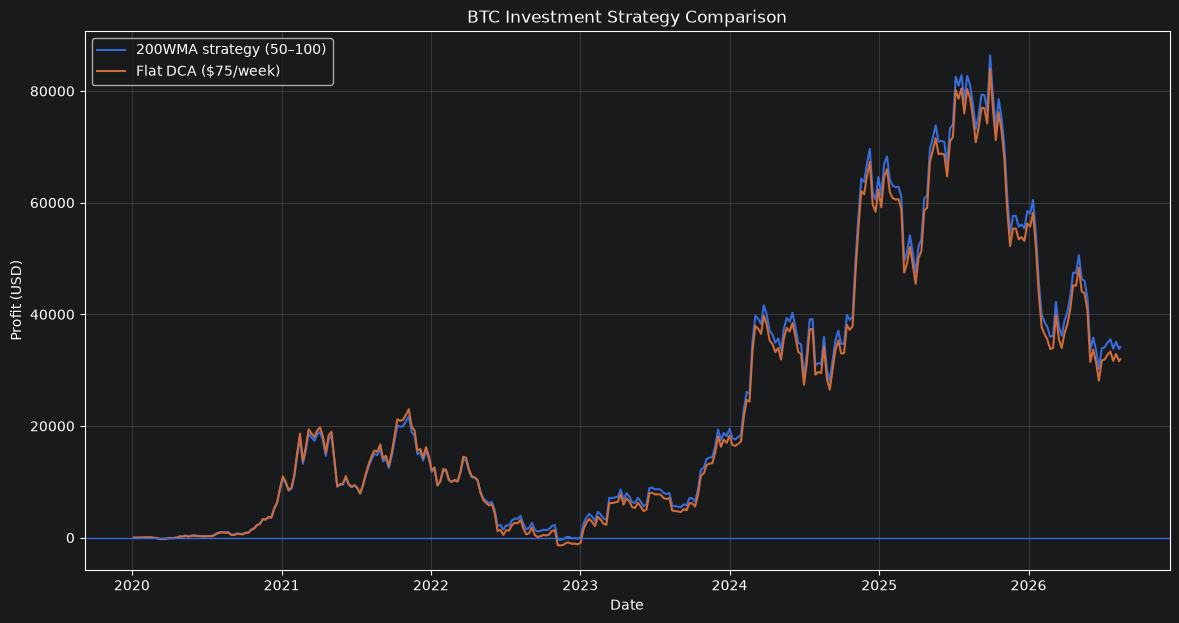

In [121]:
plt.figure(figsize=(14, 7))

plt.plot(
    btc_df["Date"],
    btc_df["profit"],
    label="200WMA strategy ($50–$100)"
)

plt.plot(
    btc_df["Date"],
    btc_df["flat_profit"],
    label="Flat DCA ($75/week)"
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("BTC Investment Strategy Comparison")
plt.xlabel("Date")
plt.ylabel("Profit (USD)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()